# Outputs for 6th Mag LGS

## Setup Materials

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from paarti.utils import maos_utils
from paarti import psfs, psf_plots

# psf_x = [0, 5, 10, 15, 20, 25, 30, 35]  # arcsec
# psf_y = [0, 0,  0,  0,  0,  0,  0,  0,  0,  0]  # arcsec
# psf_wvl = [432, 544, 652, 810, 877, 1020, 1248, 1673, 2200]

directory = '/Users/nstieg/work/ao/keck/maos/keck_maos/new_base/outputs/A_keck_scao_lgs_pre_push_test_6_15_26/'
seed = 1

%matplotlib inline

# Strehl vs. Radius

In [2]:
if directory[-1] != '/':
    directory += '/'
mets = maos_utils.get_psf_metrics_over_field(directory, seed=seed)
x, y, w, strehl, fwhm_g, fwhm_e, r_ee50, r_ee80 = mets

Looking in /Users/nstieg/work/ao/keck/maos/keck_maos/new_base/outputs/A_keck_scao_lgs_pre_push_test_6_15_26/ for simulation results...
xx =  0.0 yy =  0.0


In [4]:
r = np.sqrt(x**2 + y**2)
print(r.shape)
print(r)
print(strehl)

(1, 5)
[[0. 0. 0. 0. 0.]]
[[0.01147867 0.04578489 0.12872663 0.29699519 0.47235819]]


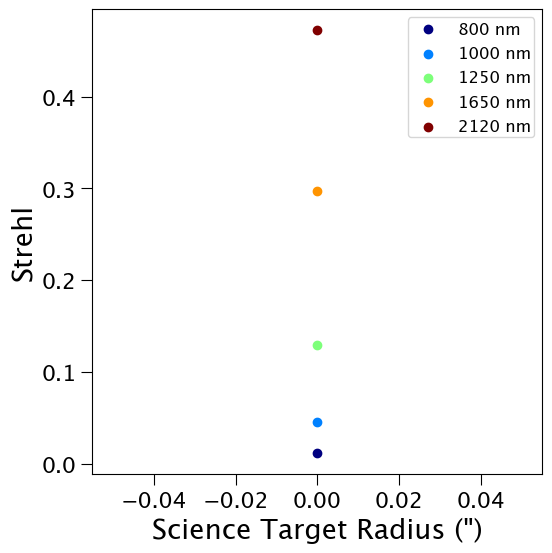

In [5]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], strehl[:, ww], color=colors[ww], label=label)    

plt.xlabel('Science Target Radius (")')
plt.ylabel('Strehl')
# plt.axvline(10, linestyle='--', color='grey', label="KLGS constellation radius")
# plt.text(31, 0.2, 'LGS radius', color='grey')
# plt.title('2026mar04 set 21 image 2')
plt.legend(fontsize=12)
plt.show()

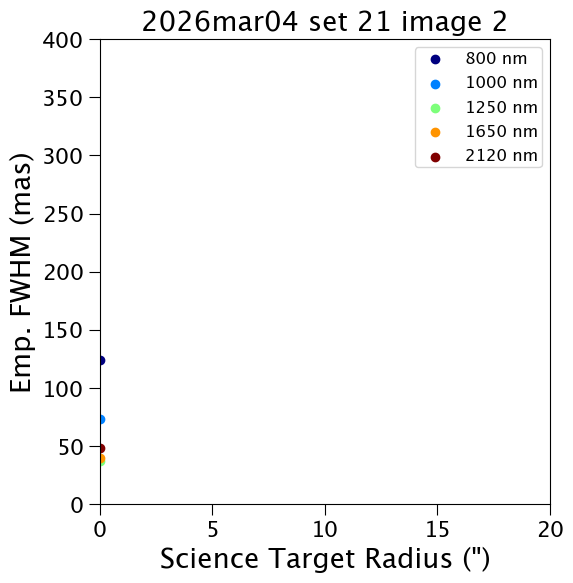

In [6]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

plt.figure(1)

for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    plt.scatter(r[:, ww], fwhm_e[:, ww], color=colors[ww], label=label)    

plt.legend(fontsize=12)
plt.xlabel('Science Target Radius (")')
plt.ylabel('Emp. FWHM (mas)')
# plt.axvline(30, linestyle='--', color='grey')
plt.xlim(0, 20)
plt.ylim(0, 400)
# plt.text(31, 0.2, 'LGS radius', color='grey')
plt.title('2026mar04 set 21 image 2')

plt.show()

(0.0, 400.0)

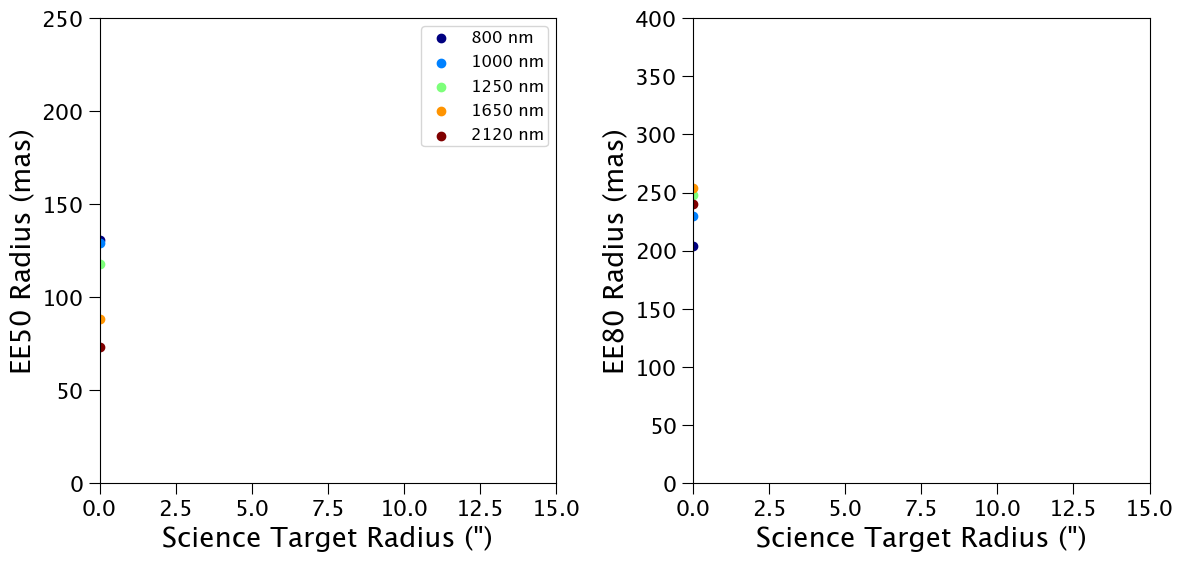

In [7]:
n_wvl = r.shape[1]
colors = plt.cm.jet(np.linspace(0,1,n_wvl))

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.subplots_adjust(wspace=0.3)
    
for ww in range(n_wvl):
    label = f'{w[0, ww]*1e3:3.0f} nm'
    axs[0].scatter(r[:, ww], r_ee50[:, ww], color=colors[ww], label=label)    
    axs[1].scatter(r[:, ww], r_ee80[:, ww], color=colors[ww])    

axs[0].legend(fontsize=12)
axs[0].set_xlabel('Science Target Radius (")')
axs[1].set_xlabel('Science Target Radius (")')
axs[0].set_ylabel('EE50 Radius (mas)')
axs[1].set_ylabel('EE80 Radius (mas)')
# axs[0].axvline(30, linestyle='--', color='grey')
# axs[1].axvline(30, linestyle='--', color='grey')
axs[0].set_xlim(0, 15)
axs[0].set_ylim(0, 250)
axs[1].set_xlim(0, 15)
axs[1].set_ylim(0, 400)
# axs[1].text(29, 20, 'LGS radius', color='grey', ha='right')

## Display PSFs.

800 nm PSFs vs. distance. 

In [8]:
# Pulled straight from maos_done.conf
nwfs = maos_utils.get_parameter_from_done_conf(directory, "powfs.nwfs")
wfs_x = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetax")
wfs_y = maos_utils.get_parameter_from_done_conf(directory, "wfs.thetay")
wvl = maos_utils.get_parameter_from_done_conf(directory, "evl.wvl")

print(nwfs)
lgs_wfs_x = wfs_x[0:nwfs[0]]
lgs_wfs_y = wfs_y[0:nwfs[0]]

ngs_wfs_x = wfs_x[nwfs[0]:nwfs[0]+nwfs[1]]
ngs_wfs_y = wfs_y[nwfs[0]:nwfs[0]+nwfs[1]]

LGSpos = np.vstack([lgs_wfs_x, lgs_wfs_y]).T
NGSpos = np.vstack([ngs_wfs_x, ngs_wfs_y]).T

# Display 650 nm PSFs
psf_stack = psfs.MAOS_PSF_stack(directory=directory, seed=seed, bandpass=2,
                               LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack.calc_metrics(parallel=True, cut_radius=30)

[1 1 1]
calc_stats in parallel with 6 cores.


In [9]:
import copy
psf_stack_35 = copy.deepcopy(psf_stack)

idx = np.where(psf_stack_35.pos[:, 0] <= 35)[0]
psf_stack_35.psfs = psf_stack_35.psfs[idx]
psf_stack_35.pos = psf_stack_35.pos[idx]


psf_plots.plot_psf_stack(psf_stack_35, zoom=None, box_scale=1.4, figsize_max=40)

/u/nstieg/code/python/paarti/paarti/psf_plots.py:176: RuntimeWarning: invalid value encountered in scalar divide
  figsize = [int(xpos_rng / asec_per_in), int(ypos_rng / asec_per_in)]


ValueError: cannot convert float NaN to integer

In [10]:
psf_stack_all_wvl = psfs.MAOS_PSF_all_bands_stack(directory=directory, seed=seed, 
                                                  LGSpos=LGSpos, NGSpos=NGSpos, isgrid=False)
psf_stack_all_wvl.calc_metrics(parallel=True)

calc_stats in parallel with 6 cores.


In [11]:
psf_plots.plot_psf_stack_xpos_all_wave(psf_stack_all_wvl, 5., zoom=0.2, figsize_max=20, box_scale=1.8)

ValueError: zero-size array to reduction operation minimum which has no identity

In [12]:
psf_stack_all_wvl.metrics


xpos,ypos,EE25,EE50,EE80,NEA,NEA2,emp_fwhm,fwhm,xfwhm,yfwhm,theta,ellipticity,strehl
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0.0,0.0,0.054312479999999996,0.09278381999999999,0.13842138999999998,0.068208346588141,0.06563753525371586,0.029556352130907772,0.09047602885914696,0.0825699153732808,0.09838214234501311,100.43741435822416,0.16072253149642668,0.011478668037077647
0.0,0.0,0.0466747875,0.0942925,0.15793993750000002,0.053918294777081995,0.050609747154053135,0.02716789609764913,0.061503961303363976,0.062106734096467456,0.06090118851026051,36.822266492306305,0.01941086749682297,0.04578488606169264
0.0,0.0,0.03653846,0.08545285,0.17208436,0.03513488497551536,0.032896334200877904,0.029214083306143033,0.036656181102810784,0.03491508379511409,0.03839727841050747,319.35265172723894,0.09068857897075511,0.1287266330235645
0.0,0.0,0.02489328,0.069234435,0.17892045,0.023830636369313648,0.02247455782128183,0.03511132319084422,0.040925045603854494,0.04162287125048617,0.04022721995722281,244.20918733409064,0.03353087500533869,0.29699519332131086
0.0,0.0,0.0249875,0.059969999999999996,0.1749125,0.021662218695305612,0.020521916275484855,0.04322636891900545,0.04900598049756571,0.04782879359688406,0.050183167398247346,175.3030504587862,0.046915607830794626,0.4723581949310028
